In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np
import pandas as pd
import numpy as np
import geopandas as gpd
from scipy import stats

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import pickle
from matplotlib.ticker import AutoMinorLocator

%pylab inline

pylab.rcParams['figure.figsize'] = (10,10)
pylab.rcParams['xtick.direction'] = 'in'
pylab.rcParams['ytick.direction'] = 'in'
pylab.rcParams['mathtext.fontset'] = 'cm'
pylab.rcParams['mathtext.rm'] = 'serif'


print('LIBRARIES LOADED!')

colors = {
    'Men': '#009E73',
    'Women': '#E69F00',
    'Men Married': '#0072B2',
    'Women Married': '#D55E00',
    'All': 'black',
    'Upper class' : '#0072B2',
    'Middle class' : '#009E73',
    'Lower class' : '#D55E00',
    "C2" : "#CC79A7",\
    "C1" : "#56B4E9",
        }

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib
LIBRARIES LOADED!


In [5]:
latin_american_gender = []

latin_american_gender.append(['São Paulo','1997', 'All', 0.8740, 0.8014, 0.9316])
latin_american_gender.append(['São Paulo','2007', 'All',0.8889, 0.8071, 0.9107])
latin_american_gender.append(['São Paulo','2017', 'All',0.8627, 0.8214, 0.9314])

latin_american_gender.append(['Bogotá','2012', 'All',0.9002, 0.6306, 0.8997])
latin_american_gender.append(['Bogotá','2019','All', 0.9065, 0.6003, 0.8168])

latin_american_gender.append(['Medellín','2005','All',0.8930, 0.7010, 0.8624])
latin_american_gender.append(['Medellín','2017','All', 0.9366, 0.5845, 0.8100])


latin_american_gender.append(['Medellín','2005','Women', 0.8930, 0.6927, 0.8567])
latin_american_gender.append(['Medellín','2017','Women', 0.9520, 0.5387, 0.8045])

latin_american_gender.append(['Medellín','2005','Men', 0.8604, 0.7065, 0.8607])
latin_american_gender.append(['Medellín','2017','Men', 0.9213, 0.6119, 0.8101])

latin_american_gender.append(['Bogotá','2012', 'Women',0.9232, 0.6148, 0.8837])
latin_american_gender.append(['Bogotá','2019','Women', 0.9048, 0.6064, 0.8115])

latin_american_gender.append(['Bogotá','2012', 'Men',0.8925, 0.6425, 0.8901])
latin_american_gender.append(['Bogotá','2019','Men', 0.9362, 0.5957, 0.8134])

latin_american_gender.append(['São Paulo','1997', 'Women', 0.8843, 0.7909, 0.9294])
latin_american_gender.append(['São Paulo','2007', 'Women',0.8910, 0.8023, 0.9120])
latin_american_gender.append(['São Paulo','2017','Women', 0.8858, 0.8106, 0.9272])


latin_american_gender.append(['São Paulo','1997', 'Men', 0.8663, 0.8072, 0.9262])
latin_american_gender.append(['São Paulo','2007', 'Men',0.8540, 0.8106, 0.9072])
latin_american_gender.append(['São Paulo','2017','Men', 0.8336, 0.8295, 0.9325])



latin_american_gender = pd.DataFrame(latin_american_gender)
latin_american_gender.columns = ['city','year','gender','hotspots_cuts_1_dest','flow_hierarchy_dest', 'mean_mob_div']
latin_american_gender['year']  = latin_american_gender['year'].astype(int)
# latin_american_gender['color'] = 'lightgrey'
latin_american_gender.head()

,city,year,gender,hotspots_cuts_1_dest,flow_hierarchy_dest,mean_mob_div
0,São Paulo,1997,All,0.8740,0.8014,0.9316
1,São Paulo,2007,All,0.8889,0.8071,0.9107
2,São Paulo,2017,All,0.8627,0.8214,0.9314
3,Bogotá,2012,All,0.9002,0.6306,0.8997
4,Bogotá,2019,All,0.9065,0.6003,0.8168


In [6]:
print(latin_american_gender[['city','year','gender','hotspots_cuts_1_dest','flow_hierarchy_dest', 'mean_mob_div']].pivot_table(columns='gender', index=['city','year']).reset_index().to_latex())

\begin{tabular}{llrrrrrrrrrr}
\toprule
 & city & year & \multicolumn{3}{r}{flow_hierarchy_dest} & \multicolumn{3}{r}{hotspots_cuts_1_dest} & \multicolumn{3}{r}{mean_mob_div} \\
gender &  &  & All & Men & Women & All & Men & Women & All & Men & Women \\
\midrule
0 & Bogotá & 2012 & 0.630600 & 0.642500 & 0.614800 & 0.900200 & 0.892500 & 0.923200 & 0.899700 & 0.890100 & 0.883700 \\
1 & Bogotá & 2019 & 0.600300 & 0.595700 & 0.606400 & 0.906500 & 0.936200 & 0.904800 & 0.816800 & 0.813400 & 0.811500 \\
2 & Medellín & 2005 & 0.701000 & 0.706500 & 0.692700 & 0.893000 & 0.860400 & 0.893000 & 0.862400 & 0.860700 & 0.856700 \\
3 & Medellín & 2017 & 0.584500 & 0.611900 & 0.538700 & 0.936600 & 0.921300 & 0.952000 & 0.810000 & 0.810100 & 0.804500 \\
4 & São Paulo & 1997 & 0.801400 & 0.807200 & 0.790900 & 0.874000 & 0.866300 & 0.884300 & 0.931600 & 0.926200 & 0.929400 \\
5 & São Paulo & 2007 & 0.807100 & 0.810600 & 0.802300 & 0.888900 & 0.854000 & 0.891000 & 0.910700 & 0.907200 & 0.912000 \\
6 & São 

In [7]:
latin_american_gender['color'] = latin_american_gender['gender'].apply(lambda x: colors[x])

In [53]:
makers = {

    "C2" : "X",\
    "C1" : "P",
        }

In [54]:
import pandas as pd
cities_usa = pd.read_csv("datasets/organised_cities_groups_2.csv")
cities_usa['color'] = cities_usa['cluster'].apply(lambda x: colors[x])
cities_usa['marker'] = cities_usa['cluster'].apply(lambda x: makers[x])
cities_usa = cities_usa[cities_usa['year']==2018]
cities_usa.head()

,Unnamed: 0,cluster,city,year,hotspots_cuts_1_dest,flow_hierarchy_dest,mean_mob_div,% of areas,Fraction of areas,color,marker
150,0,C2,San Antonio,2018,0.954315,0.556690,0.862269,0.045685,0.045685,#CC79A7,X
151,1,C2,Austin,2018,0.958333,0.678444,0.837974,0.041667,0.041667,#CC79A7,X
152,2,C2,Houston,2018,0.909931,0.669203,0.833834,0.090069,0.090069,#CC79A7,X
153,3,C1,Corpus Christi,2018,0.914286,0.822232,0.880526,0.085714,0.085714,#56B4E9,P
154,4,C2,New Orleans,2018,0.892562,0.652052,0.743010,0.107438,0.107438,#CC79A7,X


In [55]:
cities_usa

,Unnamed: 0,cluster,city,year,hotspots_cuts_1_dest,flow_hierarchy_dest,mean_mob_div,% of areas,Fraction of areas,color,marker
150,0,C2,San Antonio,2018,0.954315,0.556690,0.862269,0.045685,0.045685,#CC79A7,X
151,1,C2,Austin,2018,0.958333,0.678444,0.837974,0.041667,0.041667,#CC79A7,X
152,2,C2,Houston,2018,0.909931,0.669203,0.833834,0.090069,0.090069,#CC79A7,X
153,3,C1,Corpus Christi,2018,0.914286,0.822232,0.880526,0.085714,0.085714,#56B4E9,P
154,4,C2,New Orleans,2018,0.892562,0.652052,0.743010,0.107438,0.107438,#CC79A7,X
155,5,C2,Jacksonville,2018,0.936937,0.675612,0.847922,0.063063,0.063063,#CC79A7,X
156,6,C2,Tampa,2018,0.966102,0.688625,0.806944,0.033898,0.033898,#CC79A7,X
157,7,C1,Miami,2018,0.902439,0.808373,0.857095,0.097561,0.097561,#56B4E9,P
158,8,C2,Boston,2018,0.950000,0.574960,0.778879,0.050000,0.050000,#CC79A7,X
159,9,C2,Newark,2018,0.918367,0.819690,0.787136,0.081633,0.081633,#CC79A7,X


In [56]:
latin_american = []

latin_american.append(['São Paulo','1997', 0.8740, 0.8014, 0.9316, "o"])
latin_american.append(['São Paulo','2007', 0.8889, 0.8071, 0.9107, "o" ])
latin_american.append(['São Paulo','2017', 0.8627, 0.8214, 0.9314, "o" ])

latin_american.append(['Bogotá','2012', 0.9002, 0.6306, 0.8997, "o" ])
latin_american.append(['Bogotá','2019', 0.9065, 0.6003, 0.8168, "o" ])

latin_american.append(['Medellín','2005', 0.8930, 0.7010, 0.8624, "o" ])
latin_american.append(['Medellín','2017', 0.9366, 0.5845, 0.8100, "o" ])

latin_american = pd.DataFrame(latin_american)
latin_american.columns = ['city','year','hotspots_cuts_1_dest','flow_hierarchy_dest', 'mean_mob_div','marker']
latin_american['year']  = latin_american['year'].astype(int)
latin_american['color'] = 'lightgrey'
latin_american.head()

,city,year,hotspots_cuts_1_dest,flow_hierarchy_dest,mean_mob_div,marker,color
0,São Paulo,1997,0.8740,0.8014,0.9316,o,lightgrey
1,São Paulo,2007,0.8889,0.8071,0.9107,o,lightgrey
2,São Paulo,2017,0.8627,0.8214,0.9314,o,lightgrey
3,Bogotá,2012,0.9002,0.6306,0.8997,o,lightgrey
4,Bogotá,2019,0.9065,0.6003,0.8168,o,lightgrey


In [57]:
cities_usa['year']  = cities_usa['year'].astype(int)
all_ = pd.concat([latin_american,cities_usa[latin_american.columns]])
all_ = all_[all_['year']>2016]

In [58]:
all_.head()

,city,year,hotspots_cuts_1_dest,flow_hierarchy_dest,mean_mob_div,marker,color
2,São Paulo,2017,0.862700,0.821400,0.931400,o,lightgrey
4,Bogotá,2019,0.906500,0.600300,0.816800,o,lightgrey
6,Medellín,2017,0.936600,0.584500,0.810000,o,lightgrey
150,San Antonio,2018,0.954315,0.556690,0.862269,X,#CC79A7
151,Austin,2018,0.958333,0.678444,0.837974,X,#CC79A7


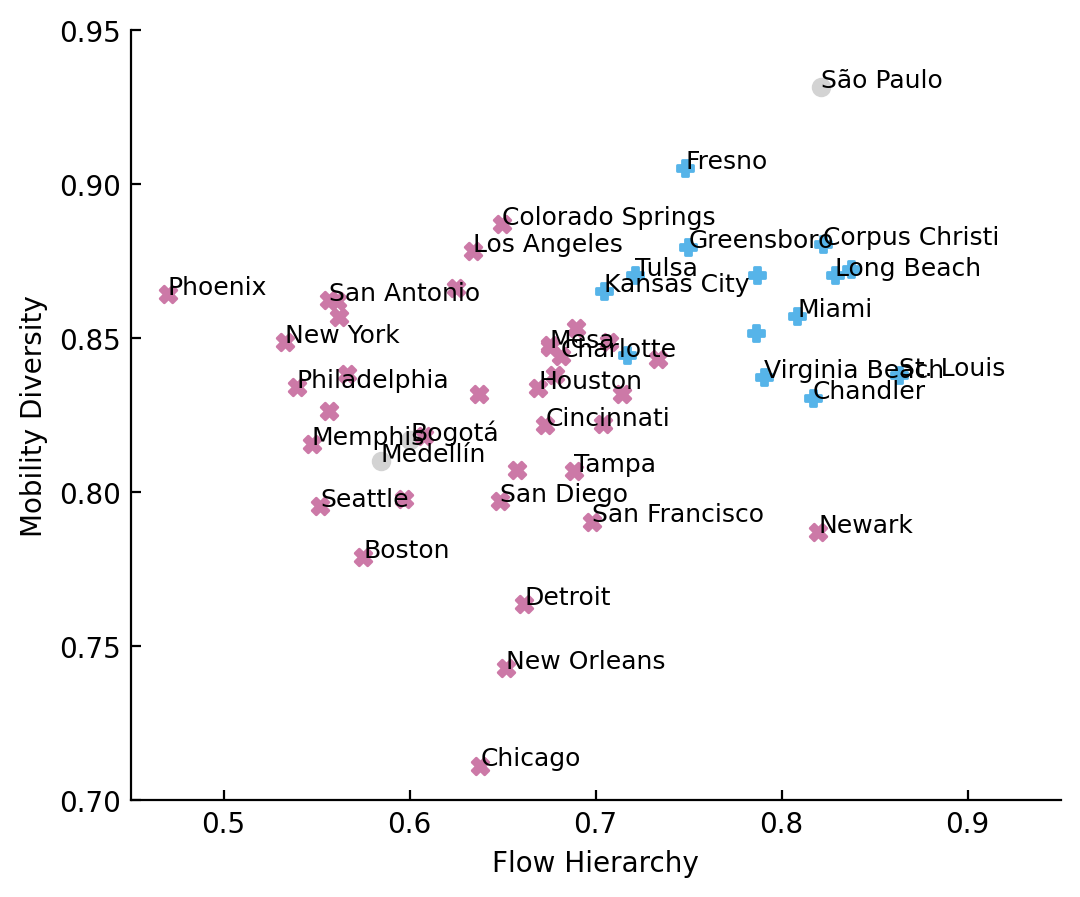

In [64]:
import seaborn as sns
fig, ax = plt.subplots(figsize=(6,5), dpi=200)

# ax.scatter(all_['flow_hierarchy_dest'],all_['mean_mob_div'],
#             s=12, color=all_['color'], marker=all_['marker'])

for m in all_['marker'].unique():
    subset = all_[all_['marker'] == m]
    colorc = all_[all_['marker'] == m]['color'].values[0]

    ax.scatter(
        subset['flow_hierarchy_dest'],
        subset['mean_mob_div'],
        color=colorc,
        marker=m,
        label=m
    )

for idx,row in all_.iterrows():
    y = row["mean_mob_div"]
    x = row["flow_hierarchy_dest"]
    text = row["city"]
    # ax.text(x+0.002,y+0.002,text, horizontalalignment='left', fontsize=9)
    if row["city"] in ['Jacksonville', 'Austin', 
        'Raleigh', 'Charslotte', 'Columbus',
       'Knoxville',  'Toledo', 
       'Indianapolis', 'Milwaukee', 
         'Dallas', 'Wichita', 'Arlington',
       'Fort Worth', 'El Paso',  'Denver', 
       'Tucson',  'Riverside',  
         'Oakland','Atlanta',
       'Sacramento', 'San Jose']:
#         ax.text(x-0.002,y+0.002,text, horizontalalignment='left', fontsize=8)
        x = 0
    else:
        ax.text(x,y,text, horizontalalignment='left', fontsize=9)
plt.xlabel("Flow Hierarchy"),
plt.ylabel("Mobility Diversity")
plt.ylim(0.70,0.95)
plt.xlim(0.45,0.95)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(True)
plt.savefig("mobdiv_flow_cities.svg")
plt.savefig("mobdiv_flow_cities.pdf")

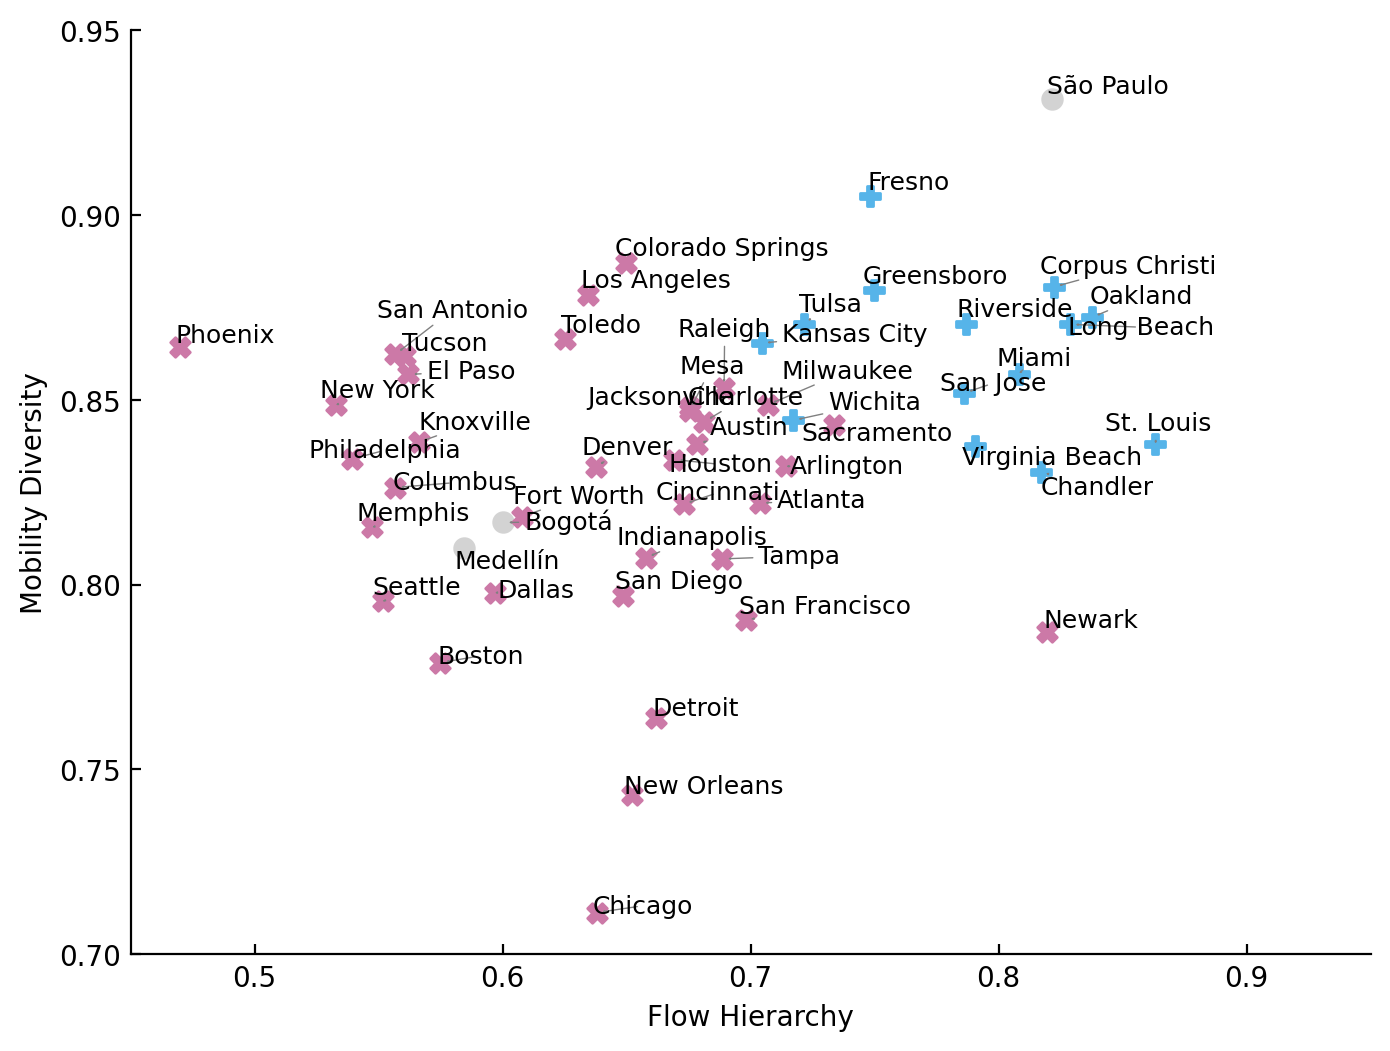

In [68]:
from adjustText import adjust_text

fig, ax = plt.subplots(figsize=(8, 6), dpi=200)

# Your scatter plot
for m in all_['marker'].unique():
    subset = all_[all_['marker'] == m]
    colorc = all_[all_['marker'] == m]['color'].values[0]
    ax.scatter(
        subset['flow_hierarchy_dest'],
        subset['mean_mob_div'],
        color=colorc,
        marker=m,
        label=m,
        s=50  # Increase size
    )

# Create text objects instead of plotting directly
texts = []
for idx, row in all_.iterrows():
    text = ax.text(
        row["flow_hierarchy_dest"],
        row["mean_mob_div"],
        row["city"],
        fontsize=9,
        ha='left'
    )
    texts.append(text)

# Automatically adjust text positions to avoid overlap
adjust_text(
    texts,
    arrowprops=dict(arrowstyle='->', color='gray', lw=0.5),
    ax=ax
)

plt.xlabel("Flow Hierarchy")
plt.ylabel("Mobility Diversity")
plt.ylim(0.70, 0.95)
plt.xlim(0.45, 0.95)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.savefig("mobdiv_flow_cities.pdf", bbox_inches='tight')